#Code used for the production of the figures used in Chapter 6 of N Haket's PhD

## Production of Word2Vec embeddings for *lemon, apple, queen, king, cat, dog, freedom, racism*

In [ ]:
!pip install gensim


In [ ]:
import gensim.downloader as api
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Load pre-trained Word2Vec model (Google News)
model = api.load("word2vec-google-news-300")

# List of words to visualize
words = ['man', 'woman', 'king', 'lemon', 'apple', 'dog', 'cat', 'queen', 'freedom', 'racism']

# Get the embeddings for the selected words
X = np.array([model[word] for word in words])

# Apply PCA for 2D visualization
pca = PCA(n_components=2)
result = pca.fit_transform(X)

# Create a DataFrame for plotting
df = pd.DataFrame(result, columns=['X', 'Y'])
df['Words'] = words



[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [ ]:
!apt install texlive-fonts-recommended texlive-fonts-extra cm-super dvipng


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  cm-super-minimal dvisvgm fonts-adf-accanthis fonts-adf-berenis
  fonts-adf-gillius fonts-adf-universalis fonts-cabin fonts-cantarell
  fonts-comfortaa fonts-croscore fonts-crosextra-caladea
  fonts-crosextra-carlito fonts-dejavu-core fonts-dejavu-extra
  fonts-droid-fallback fonts-ebgaramond fonts-ebgaramond-extra
  fonts-font-awesome fonts-freefont-otf fonts-freefont-ttf fonts-gfs-artemisia
  fonts-gfs-complutum fonts-gfs-didot fonts-gfs-neohellenic fonts-gfs-olga
  fonts-gfs-solomos fonts-go fonts-junicode fonts-lato fonts-linuxlibertine
  fonts-lmodern fonts-lobster fonts-lobstertwo fonts-noto-color-emoji
  fonts-noto-core fonts-noto-mono fonts-oflb-asana-math fonts-open-sans
  fonts-roboto-unhinted fonts-sil-charis fonts-sil-gentium
  fonts-sil-gentium-basic fonts-sil-gentiumplus fonts-sil-gentiumplus-compact
  fonts-stix fonts-texg

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True

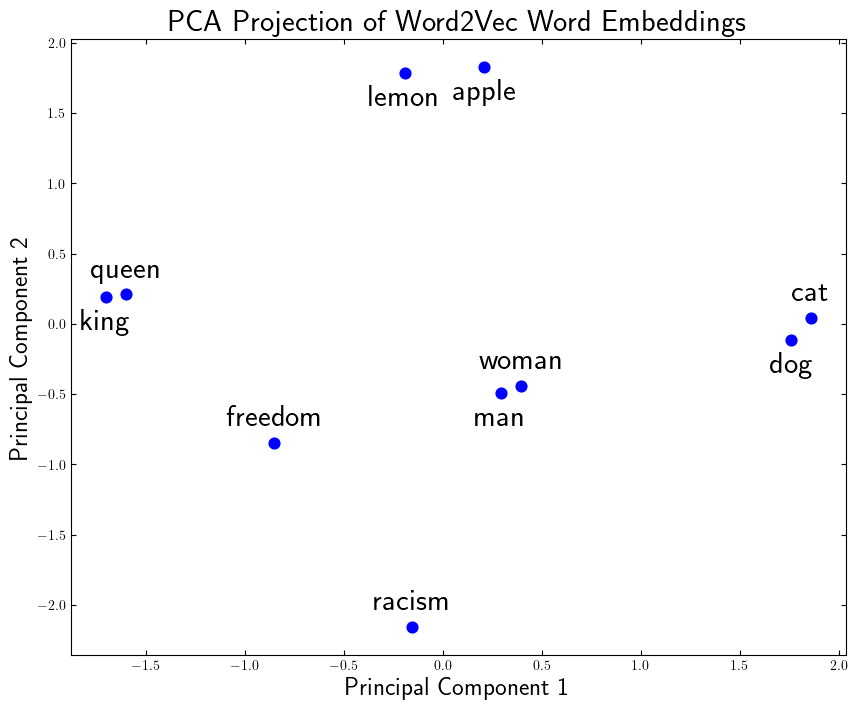

In [ ]:
# Plotting the embeddings with Matplotlib
plt.figure(figsize=(10, 8))  # Set figure size

# Scatter plot
plt.scatter(df['X'], df['Y'], c='blue', s=60)  # Use df columns for x and y

# Add custom text labels with positions
for i, word in enumerate(df['Words']):
    if word in ['man', 'king', 'lemon', 'apple', 'dog']:
        # Place the words "man" and "king" below the points
        plt.text(df['X'][i], df['Y'][i] - 0.08, word, fontsize=22, ha='center', va='top')
    else:
        # Place other words above the points
        plt.text(df['X'][i], df['Y'][i] + 0.08, word, fontsize=22, ha='center', va='bottom')

# Titles and labels
plt.title("PCA Projection of Word2Vec Word Embeddings", fontsize=22)
plt.xlabel("Principal Component 1", fontsize=18)
plt.ylabel("Principal Component 2", fontsize=18)

# Show the plot
plt.show()


## Production of BERT embedding PCA graphs for *charge*

In [ ]:
import torch
from transformers import BertTokenizer, BertModel
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Step 1: Define sentences
sentences = [
    "He will charge his phone before leaving.",
    "The police charge the suspect with theft.",
    "The knight will charge into battle bravely.",
    "They charge a fee for late returns.",
    "The lawyer will charge by the hour.",
    "The students charge into the cafeteria at lunchtime.",
    "The credit card will charge an interest fee.",
    "The teacher will charge the class with completing the project.",
    "The soldiers charge at the enemy line.",
    "The bull will charge at the red cloth.",
    "He will charge his laptop overnight.",
    "The store will charge extra for delivery.",
    "She will charge the battery before the trip.",
    "The bank will charge for international transactions.",
    "The coach will charge the team with playing aggressively.",
    "The court will charge the company with fraud.",
    "The scientist will charge the particles with static electricity.",
    "He will charge his smartwatch before the marathon.",
    "The lawyer will charge his client for additional services.",
    "The prosecutor will charge him in court next week.",
    "The parents will charge their children with household tasks.",
    "The electric car will charge overnight.",
    "The landlord will charge a security deposit.",
    "The crowd will charge toward the stage.",
    "The battery will charge fully in an hour.",
    "The artist will charge for commissioned work.",
    "The general will charge his troops with defending the fort.",
    "The restaurant will charge for extra toppings.",
    "The government will charge companies for pollution.",
    "The bullfighter will charge at the animal.",
    "The coach will charge his players with responsibility.",
    "The professor will charge the students with conducting research.",
    "The bank will charge an overdraft fee.",
    "The knight will charge toward the castle gates.",
    "The prosecutor will charge the gang with multiple crimes.",
    "The storm clouds charge the air with electricity.",
    "The train will charge down the tracks.",
    "The inspector will charge the builder with safety violations.",
    "The journalist will charge the company with corruption allegations.",
    "The battery will charge faster with a high-power adapter.",
    "The lawyer will charge a retainer fee.",
    "The army will charge the enemy's fortress.",
    "The credit card company will charge a monthly fee.",
    "The judge will charge the jury with reaching a verdict.",
    "The protesters charge at the police barricade.",
    "The wind will charge the atmosphere before the storm.",
    "The department store will charge for gift wrapping.",
    "The scientist will charge the metal with an electric current.",
    "The students will charge forward when the race begins.",
    "The government will charge for water usage.",
    "The child will charge across the playground.",
    "The supplier will charge for expedited shipping.",
    "The crowd will charge through the open gates.",
    "The supervisor will charge the team with completing the project on time.",
    "The horse will charge toward the obstacle.",
    "The accountant will charge for consultation.",
    "The engineer will charge the battery pack before installation.",
    "The criminal will charge at the police in a desperate attempt.",
    "The committee will charge its members with investigating the issue.",
    "The mobile network will charge for excess data usage.",
    "The store will charge a fee for plastic bags.",
    "The scientist will charge the experiment with high voltage.",
    "The landlord will charge rent at the start of each month.",
    "The guards will charge at the intruders.",
    "The retailer will charge extra for international orders.",
    "The dog will charge toward the mailman.",
    "The professor will charge his students with analyzing the data.",
    "The judge will charge the defendant with contempt of court.",
    "The hikers will charge up the steep hill.",
    "The delivery service will charge for same-day shipping.",
    "The historian will charge the king with making unfair policies.",
    "The football team will charge at the opposition's defense.",
    "The police will charge the protestors with disorderly conduct.",
    "The thunderstorm will charge the air with static energy.",
    "The journalist will charge the official with covering up the scandal.",
    "The concert venue will charge for parking.",
    "The soldiers will charge into battle.",
    "The security guard will charge at the intruder.",
    "The vendor will charge extra for rush orders.",
    "The detective will charge the suspect with conspiracy.",
    "The research team will charge their equipment before the fieldwork.",
    "The animals will charge across the open plains.",
    "The protesters will charge forward in defiance.",
    "The police will charge the motorist with reckless driving.",
    "The lawyer will charge for every consultation.",
    "The mechanic will charge for labor and materials.",
    "The prosecutor will charge the suspect with fraud.",
    "The marathon runner will charge ahead in the final lap.",
    "The concert organizers will charge extra for VIP access.",
    "The coach will charge his team with staying motivated.",
    "The economist will charge corporations with exploiting workers.",
    "The scientist will charge the chamber with purified air.",
    "The software developer will charge a fee for premium features.",
    "The referee will charge the player with a foul.",
    "The landlord will charge a late fee for overdue rent."
]

# Step 2: Initialize the BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

# Step 3: Define the target word
target_word = "charge"  # Target word for embeddings

# Step 4: Function to get the BERT embeddings for the target word
def get_word_embedding(sentence, target_word):
    # Tokenize the sentence
    inputs = tokenizer(sentence, return_tensors='pt', add_special_tokens=True)
    with torch.no_grad():
        outputs = model(**inputs)

    # Get embeddings for each token
    token_embeddings = outputs.last_hidden_state.squeeze(0)
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'].squeeze(0))

    # Find the index of the target word
    try:
        target_index = tokens.index(target_word)
    except ValueError:
        print(f"'{target_word}' not found in sentence: '{sentence}'")
        return None

    # Get the embedding for the target word
    target_embedding = token_embeddings[target_index]

    return target_embedding

# Step 5: Get embeddings for all sentences
embeddings = []
for sentence in sentences:
    embedding = get_word_embedding(sentence, target_word)
    if embedding is not None:
        embeddings.append(embedding.numpy())




/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

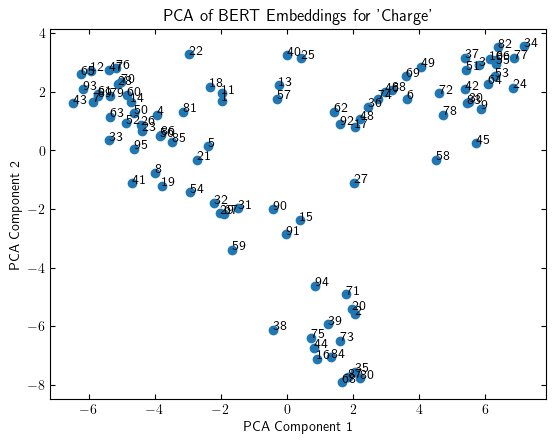

In [ ]:
# Step 6: Use PCA to reduce the dimensions to 2D
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

# Step 7: Plot the 2D projections
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1])
for i, sentence in enumerate(sentences):
    plt.annotate(f"{i+1}", (embeddings_2d[i, 0], embeddings_2d[i, 1]))
plt.title("PCA of BERT Embeddings for 'Charge'")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.savefig("charge_embeddings_pca.png", dpi=300, bbox_inches='tight')
plt.show()

## Production of BERT embedding PCA graphs for *Accident*

In [ ]:
import torch
from transformers import BertTokenizer, BertModel
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Step 1: Define sentences
# Step 1: Define sentences
sentences = [
    "He deleted the important document by accident and couldn't recover it.",
    "She sent the text to the wrong person by accident.",
    "They met in the bookstore by accident after years apart.",
    "He knocked over his coffee by accident during the meeting.",
    "The file got permanently erased by accident.",
    "She clicked the wrong button by accident and closed the window.",
    "He turned onto the wrong street by accident and got lost.",
    "She dialed the wrong number by accident and ended up chatting with a stranger.",
    "The child spilled juice on the carpet by accident.",
    "He revealed the surprise party plans by accident.",
    "She walked into the wrong classroom by accident.",
    "I stepped on his shoe by accident in the crowded train.",
    "He changed the TV channel by accident and missed the ending.",
    "The dog got out of the yard by accident when the gate was left open.",
    "She booked the wrong flight by accident and had to reschedule.",
    "He sent the confidential email to the wrong address by accident.",
    "I deleted all my notes by accident before the exam.",
    "The waiter mixed up the orders by accident.",
    "She put salt instead of sugar in the cake by accident.",
    "He forwarded the email to his boss by accident.",
    "The toddler turned off the TV by accident.",
    "She switched the labels on the files by accident.",
    "He left the stove on by accident before going to bed.",
    "I entered the wrong password too many times by accident.",
    "She dropped her phone in the sink by accident.",
    "The student skipped a question on the exam by accident.",
    "He spilled ink on the report by accident.",
    "I left my umbrella on the bus by accident.",
    "She walked into the wrong apartment by accident.",
    "He picked up someone else's bag by accident.",
    "She activated airplane mode by accident and missed the call.",
    "He turned off his alarm by accident and overslept.",
    "I bought the wrong size by accident while shopping online.",
    "She knocked over the chessboard by accident during the game.",
    "He posted the draft version of the report by accident.",
    "She called her teacher 'Mom' by accident in class.",
    "He locked himself out of his car by accident.",
    "She sent a blurry photo by accident instead of the clear one.",
    "He replied to all by accident in the email thread.",
    "She clicked the unsubscribe button by accident.",
    "He muted the microphone by accident during the presentation.",
    "I turned off the heating by accident last night.",
    "She deleted her social media account by accident.",
    "The cat jumped on the keyboard by accident and typed nonsense.",
    "He left his wallet at the restaurant by accident.",
    "She flipped to the wrong page by accident during the test.",
    "He removed the file from the shared drive by accident.",
    "She shared the wrong link by accident in the group chat.",

    "The car accident blocked traffic for hours.",
    "She was injured in a minor accident at work.",
    "The accident caused significant damage to the building.",
    "They investigated the cause of the airplane accident.",
    "His bike accident left him with a broken arm.",
    "The factory accident resulted in stricter safety measures.",
    "The accident at the construction site halted all work.",
    "The pilot managed to avoid a major accident.",
    "The train accident was reported on the evening news.",
    "She slipped on the ice and had a small accident.",
    "The accident was unavoidable given the road conditions.",
    "The accident report was filled out by the officer.",
    "They witnessed the accident while crossing the street.",
    "The accident in the lab led to new safety protocols.",
    "The firefighter responded quickly to the accident.",
    "The accident left a dent in the car door.",
    "His accident delayed their vacation plans.",
    "The accident at the theme park raised safety concerns.",
    "The boating accident was caused by strong winds.",
    "The truck accident resulted in a fuel spill.",
    "The mountain climbing accident was a tragic event.",
    "The accident occurred due to a mechanical failure.",
    "Her accident led to a hospital visit.",
    "The accident caused a power outage in the area.",
    "The accident happened right outside their house.",
    "The doctor treated the patient after the accident.",
    "The accident disrupted the morning commute.",
    "His accident insurance covered the hospital costs.",
    "The oil spill was caused by an industrial accident.",
    "The playground accident gave him a scraped knee.",
    "The elevator accident was a rare malfunction.",
    "The skiing accident ended her season early.",
    "The accident investigation took weeks to complete.",
    "The accident resulted in a lawsuit.",
    "The racing accident shocked the audience.",
    "The fall was an unfortunate accident.",
    "The workplace accident led to new training programs.",
    "The cyclist recovered quickly from the accident.",
    "The car accident involved three vehicles.",
    "The accident led to a discussion on road safety.",
    "The accident was caught on a security camera.",
    "The construction accident injured two workers.",
    "The lab accident resulted in a chemical spill.",
    "The ship accident was due to navigational errors.",
    "The accident on the highway caused a massive traffic jam.",
    "The accident was reported immediately to emergency services.",
    "His accident was caused by distraction.",
    "The amusement park accident led to ride inspections.",
    "The warehouse accident delayed deliveries.",
    "The factory accident required emergency responders.",
    "The accident on the set paused film production.",
    "The car accident was ruled a case of reckless driving."
]




# Step 2: Initialize the BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

# Step 3: Define the target word
target_word = "accident"  # Target word for embeddings

# Step 4: Function to get the BERT embeddings for the target word
def get_word_embedding(sentence, target_word):
    # Tokenize the sentence
    inputs = tokenizer(sentence, return_tensors='pt', add_special_tokens=True)
    with torch.no_grad():
        outputs = model(**inputs)

    # Get embeddings for each token
    token_embeddings = outputs.last_hidden_state.squeeze(0)
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'].squeeze(0))

    # Find the index of the target word
    try:
        target_index = tokens.index(target_word)
    except ValueError:
        print(f"'{target_word}' not found in sentence: '{sentence}'")
        return None

    # Get the embedding for the target word
    target_embedding = token_embeddings[target_index]

    return target_embedding

# Step 5: Get embeddings for all sentences
embeddings = []
for sentence in sentences:
    embedding = get_word_embedding(sentence, target_word)
    if embedding is not None:
        embeddings.append(embedding.numpy())




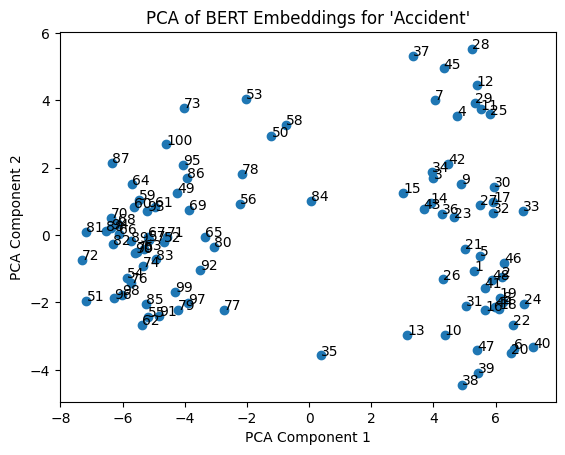

In [ ]:
# Step 6: Use PCA to reduce the dimensions to 2D
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

# Step 7: Plot the 2D projections
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1])
for i, sentence in enumerate(sentences):
    plt.annotate(f"{i+1}", (embeddings_2d[i, 0], embeddings_2d[i, 1]))
plt.title("PCA of BERT Embeddings for 'Accident'")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

## Production of meaning Dimensions on PCA Graphs

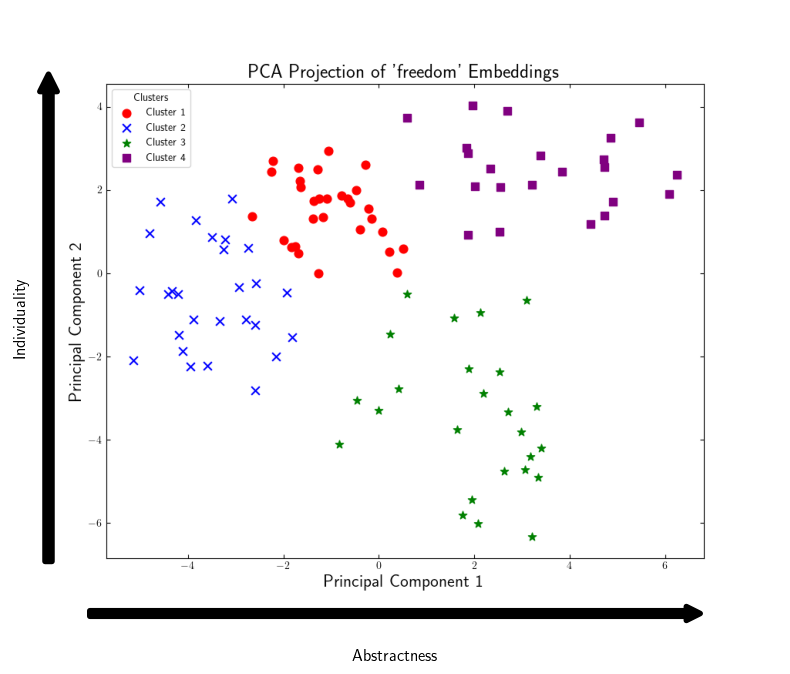

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import matplotlib.image as mpimg

# Define the file paths
output_folder = 'X'
filename = 'pca_freedom.png'  # Original filename
new_filename = filename.replace('.png', '_dimensions.png')  # Append '_dimensions' to the filename
image_path = os.path.join(output_folder, filename)

# Load the existing PCA image
img = mpimg.imread(image_path)

# Create a new figure and display the image as a background
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(img)  # Display the original PCA plot

# Remove axis labels and ticks to keep it clean
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)

# Add an arrow pointing straight up on the far left side
ax.annotate(
    "",  # No text label
    xy=(0.05, 0.9),  # Arrow tip (higher position, further left)
    xytext=(0.05, 0.1),  # Arrow tail (lower position, further left)
    xycoords='axes fraction',  # Relative positioning
    arrowprops=dict(facecolor='black', arrowstyle='simple', linewidth=4, mutation_scale=25)  # Correct arrow style
)

# Add vertical text along the arrow (centered along the vertical arrow) and moved further left
ax.text(
    0.015,  # Move the text further left (lower x value)
    0.5,    # Y-coordinate of the text (centered along the arrow)
    "Individuality",   # The text you want to display
    ha='center',  # Horizontal alignment (centered)
    va='center',  # Vertical alignment (centered)
    fontsize=12,  # Font size
    color='black',  # Text color
    rotation=90,  # Rotate the text to be vertical
    transform=ax.transAxes  # Ensure the text is placed relative to the axes
)

# Add an arrow at the bottom moving from left to right (lower position)
ax.annotate(
    "",  # No text label
    xy=(0.9, 0.02),  # Arrow tip (further right, lower position)
    xytext=(0.1, 0.02),  # Arrow tail (further left, lower position)
    xycoords='axes fraction',  # Relative positioning
    arrowprops=dict(facecolor='black', arrowstyle='simple', linewidth=4, mutation_scale=20)  # Cartoonish arrow style
)

# Add text underneath the arrow
ax.text(
    0.5,  # X-coordinate of the text (centered horizontally)
    -0.05,  # Y-coordinate of the text (positioned below the arrow)
    "Abstractness",  # The text you want to display
    ha='center',  # Horizontal alignment (centered)
    va='center',  # Vertical alignment (centered)
    fontsize=12,  # Font size
    color='black',  # Text color
    transform=ax.transAxes  # Ensure the text is placed relative to the axes
)

# Save the updated figure
plt.savefig(os.path.join(output_folder, new_filename), bbox_inches='tight', dpi=600)

# Close the figure to free up memory
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import matplotlib.image as mpimg

# Define the file paths
output_folder = 'X'
filename = 'pca_planet.png'  # Original filename
new_filename = filename.replace('.png', '_dimensions.png')  # Append '_dimensions' to the filename
image_path = os.path.join(output_folder, filename)

# Load the existing PCA image
img = mpimg.imread(image_path)

# Create a new figure and display the image as a background
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(img)  # Display the original PCA plot

# Remove axis labels and ticks to keep it clean
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)

# Add an arrow pointing straight up on the far left side
ax.annotate(
    "",  # No text label
    xy=(0.05, 0.9),  # Arrow tip (higher position, further left)
    xytext=(0.05, 0.1),  # Arrow tail (lower position, further left)
    xycoords='axes fraction',  # Relative positioning
    arrowprops=dict(facecolor='black', arrowstyle='simple', linewidth=4, mutation_scale=25)  # Correct arrow style
)

# Add vertical text along the arrow (centered along the vertical arrow) and moved further left
ax.text(
    0.015,  # Move the text further left (lower x value)
    0.5,    # Y-coordinate of the text (centered along the arrow)
    "Literality",   # The text you want to display
    ha='center',  # Horizontal alignment (centered)
    va='center',  # Vertical alignment (centered)
    fontsize=12,  # Font size
    color='black',  # Text color
    rotation=90,  # Rotate the text to be vertical
    transform=ax.transAxes  # Ensure the text is placed relative to the axes
)

# Add an arrow at the bottom moving from left to right (lower position)
ax.annotate(
    "",  # No text label
    xy=(0.9, 0.02),  # Arrow tip (further right, lower position)
    xytext=(0.1, 0.02),  # Arrow tail (further left, lower position)
    xycoords='axes fraction',  # Relative positioning
    arrowprops=dict(facecolor='black', arrowstyle='simple', linewidth=4, mutation_scale=20)  # Cartoonish arrow style
)

# Add text underneath the arrow
ax.text(
    0.5,  # X-coordinate of the text (centered horizontally)
    -0.05,  # Y-coordinate of the text (positioned below the arrow)
    "Scientific --> Social",  # The text you want to display
    ha='center',  # Horizontal alignment (centered)
    va='center',  # Vertical alignment (centered)
    fontsize=12,  # Font size
    color='black',  # Text color
    transform=ax.transAxes  # Ensure the text is placed relative to the axes
)

# Save the updated figure
plt.savefig(os.path.join(output_folder, new_filename), bbox_inches='tight', dpi=300)

# Close the figure to free up memory
plt.savefig("freedom dimensions.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import matplotlib.image as mpimg

# Define the file paths
output_folder = 'X'
filename = 'pca_theory.png'  # Original filename
new_filename = filename.replace('.png', '_dimensions.png')  # Append '_dimensions' to the filename
image_path = os.path.join(output_folder, filename)

# Load the existing PCA image
img = mpimg.imread(image_path)

# Create a new figure and display the image as a background
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(img)  # Display the original PCA plot

# Remove axis labels and ticks to keep it clean
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)

# Add an arrow pointing straight up on the far left side
ax.annotate(
    "",  # No text label
    xy=(0.05, 0.9),  # Arrow tip (higher position, further left)
    xytext=(0.05, 0.1),  # Arrow tail (lower position, further left)
    xycoords='axes fraction',  # Relative positioning
    arrowprops=dict(facecolor='black', arrowstyle='simple', linewidth=4, mutation_scale=25)  # Correct arrow style
)

# Add vertical text along the arrow (centered along the vertical arrow) and moved further left
ax.text(
    0.015,  # Move the text further left (lower x value)
    0.5,    # Y-coordinate of the text (centered along the arrow)
    "Shared/Objective --> Invididual/Subjective",   # The text you want to display
    ha='center',  # Horizontal alignment (centered)
    va='center',  # Vertical alignment (centered)
    fontsize=12,  # Font size
    color='black',  # Text color
    rotation=90,  # Rotate the text to be vertical
    transform=ax.transAxes  # Ensure the text is placed relative to the axes
)

# Add an arrow at the bottom moving from left to right (lower position)
ax.annotate(
    "",  # No text label
    xy=(0.9, 0.02),  # Arrow tip (further right, lower position)
    xytext=(0.1, 0.02),  # Arrow tail (further left, lower position)
    xycoords='axes fraction',  # Relative positioning
    arrowprops=dict(facecolor='black', arrowstyle='simple', linewidth=4, mutation_scale=20)  # Cartoonish arrow style
)

# Add text underneath the arrow
ax.text(
    0.5,  # X-coordinate of the text (centered horizontally)
    -0.05,  # Y-coordinate of the text (positioned below the arrow)
    "Certainty",  # The text you want to display
    ha='center',  # Horizontal alignment (centered)
    va='center',  # Vertical alignment (centered)
    fontsize=12,  # Font size
    color='black',  # Text color
    transform=ax.transAxes  # Ensure the text is placed relative to the axes
)

# Save the updated figure
plt.savefig(os.path.join(output_folder, new_filename), bbox_inches='tight', dpi=300)

# Close the figure to free up memory
plt.show()
